# 02 — Feature Engineering & Logistic Regression Baseline

Builds the model feature space (see `src/features.py`) and trains an **explainable baseline**: Logistic Regression with `class_weight='balanced'` to counter the 0.58% fraud rate. Evaluated on the **held-out test file** using the metrics that matter for rare-positive detection.

**Why LogReg first?** It is simple, fast, and auditable — a bank's risk team can read the coefficients. It sets the bar every later model (RandomForest, XGBoost) must beat.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110

import features as F
X_train, y_train, X_test, y_test = F.load_train_test()
print("train:", X_train.shape, "| fraud:", int(y_train.sum()))
print("test :", X_test.shape, "| fraud:", int(y_test.sum()))
print("features:", list(X_train.columns))

train: (1296675, 23) | fraud: 7506
test : (555719, 23) | fraud: 2145
features: ['log_amt', 'amt', 'hour', 'is_night', 'day_of_week', 'is_weekend', 'age', 'log_city_pop', 'gender_M', 'cat_entertainment', 'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net', 'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets', 'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net', 'cat_shopping_pos', 'cat_travel']


## Train the baseline

Pipeline = `StandardScaler` (LogReg needs scaled inputs) → `LogisticRegression(class_weight='balanced')`.

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
])
pipe.fit(X_train, y_train)
proba = pipe.predict_proba(X_test)[:, 1]
print("trained.")

trained.


## Evaluation — the metrics that matter

We report **PR-AUC** (the headline for imbalanced data), ROC-AUC, and the full precision/recall trade-off — not accuracy.

In [3]:
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             precision_recall_curve)

pr_auc = average_precision_score(y_test, proba)
roc_auc = roc_auc_score(y_test, proba)
print(f"PR-AUC : {pr_auc:.4f}   (baseline rate = {y_test.mean():.4f})")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\n--- Default threshold = 0.50 ---")
pred_05 = (proba >= 0.5).astype(int)
print(classification_report(y_test, pred_05, digits=4, target_names=["legit", "fraud"]))

PR-AUC : 0.1843   (baseline rate = 0.0039)
ROC-AUC: 0.9641

--- Default threshold = 0.50 ---
              precision    recall  f1-score   support

       legit     0.9997    0.8887    0.9409    553574
       fraud     0.0312    0.9254    0.0604      2145

    accuracy                         0.8889    555719
   macro avg     0.5154    0.9071    0.5007    555719
weighted avg     0.9959    0.8889    0.9375    555719



## Choosing an operating threshold (business lever)

The default 0.5 is rarely what a bank wants. We pick the threshold that **maximises F1**, then show the recall/precision it delivers. (Later we can tune this to a target recall, e.g. "catch 90% of fraud".)

In [4]:
prec, rec, thr = precision_recall_curve(y_test, proba)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best = np.nanargmax(f1[:-1])
best_thr = thr[best]
print(f"Best-F1 threshold = {best_thr:.3f}  ->  precision={prec[best]:.3f}, recall={rec[best]:.3f}, F1={f1[best]:.3f}")

pred_best = (proba >= best_thr).astype(int)
cm = confusion_matrix(y_test, pred_best)
print("\nConfusion matrix @ best-F1 threshold:")
print(pd.DataFrame(cm, index=["actual_legit", "actual_fraud"], columns=["pred_legit", "pred_fraud"]))

Best-F1 threshold = 0.936  ->  precision=0.286, recall=0.584, F1=0.384

Confusion matrix @ best-F1 threshold:
              pred_legit  pred_fraud
actual_legit      550445        3129
actual_fraud         892        1253


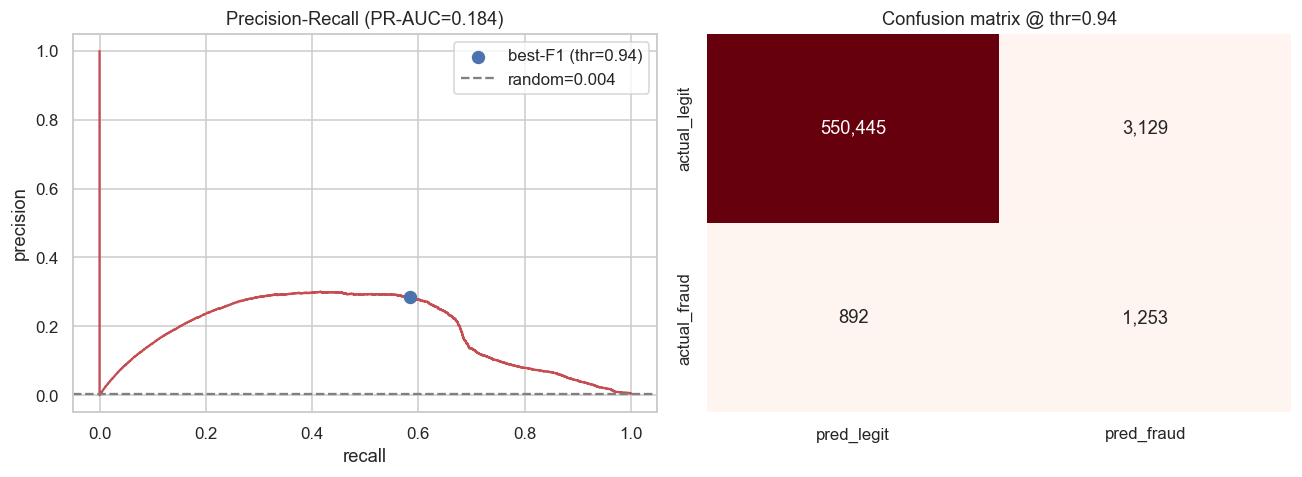

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(rec, prec, color="#c44e52")
ax[0].scatter(rec[best], prec[best], s=60, zorder=5, label=f"best-F1 (thr={best_thr:.2f})")
ax[0].axhline(y_test.mean(), ls="--", color="gray", label=f"random={y_test.mean():.3f}")
ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision")
ax[0].set_title(f"Precision-Recall (PR-AUC={pr_auc:.3f})"); ax[0].legend()

sns.heatmap(cm, annot=True, fmt=",d", cmap="Reds", cbar=False, ax=ax[1],
            xticklabels=["pred_legit", "pred_fraud"], yticklabels=["actual_legit", "actual_fraud"])
ax[1].set_title(f"Confusion matrix @ thr={best_thr:.2f}")
fig.tight_layout(); fig.savefig(FIG / "05_baseline_pr_confusion.png"); plt.show()

## Coefficients — what the baseline learned (explainability)

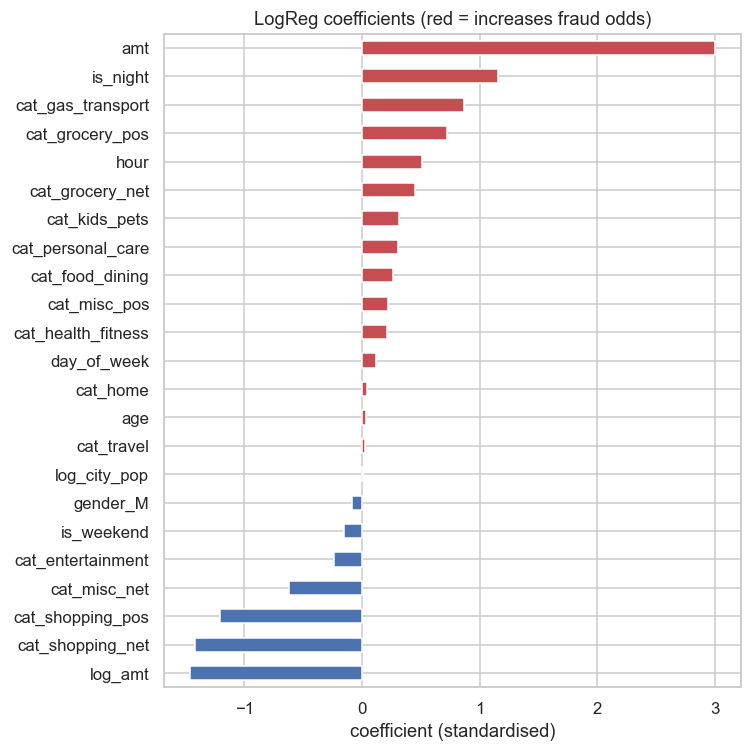

In [6]:
coefs = pd.Series(pipe.named_steps["clf"].coef_[0], index=X_train.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
colors = ["#c44e52" if v > 0 else "#4c72b0" for v in coefs.values]
coefs.plot.barh(ax=ax, color=colors)
ax.set_title("LogReg coefficients (red = increases fraud odds)")
ax.set_xlabel("coefficient (standardised)")
fig.tight_layout(); fig.savefig(FIG / "06_baseline_coefficients.png"); plt.show()

## Baseline summary

This is the **bar to beat**. The PR-AUC and recall numbers above become the reference for the next iterations:

1. **RandomForest** — capture non-linear interactions (e.g. high-amount AND night AND online category).
2. **XGBoost** with `scale_pos_weight` — typically the strongest tabular fraud model.
3. **Threshold tuned to a business target** (e.g. 90% recall) + **SHAP** explainability.

Result metrics are saved to figures for the final business-impact report.